In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.fft import fft, fftfreq  #importamos (Fast Fourier Transform) para el análisis de frecuencia y fftfreq para obtener las frecuencias correspondientes a cada componente de la FFT

data = loadmat("signals.mat")#Diccionario
print(data.keys())#Extraigo las claves del diccionario


dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [2]:
#FUNCIÓN RMS
def rms(signal):
    return np.sqrt(np.mean(signal**2))#Calcula el valor RMS mediante el promedio(mean) de los cuadrados de la señal

Duración de la señal: 30.0 segundos
2003.3280873578112
-685.6954452075946


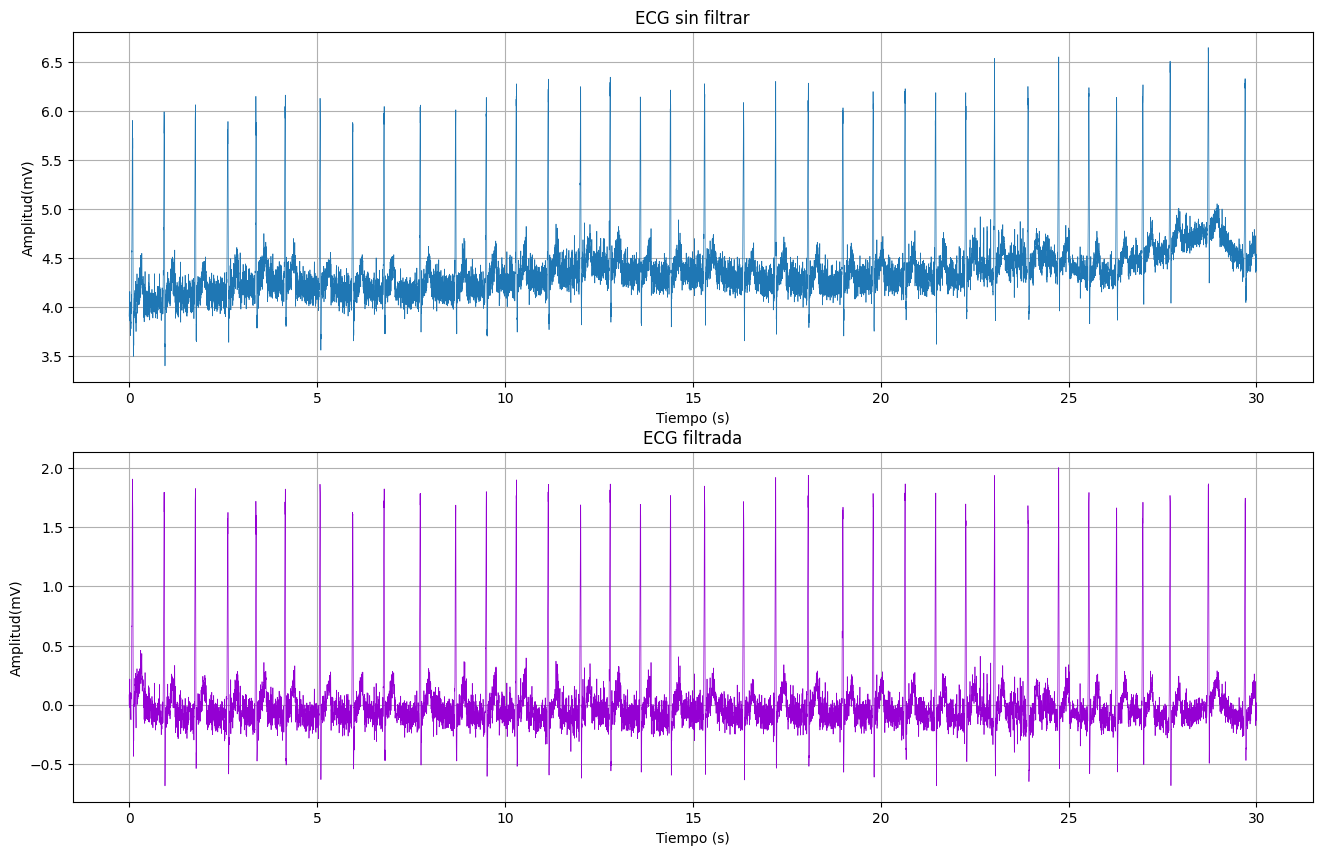

In [4]:
#GRÁFICO DE LA SEÑAL

#señal sin filtrar
ecg_unfiltered = data['ECG_asRecording']#señal sin filtrar
#Extraigo la señal ECG filtrada del diccionario utilizando la clave 'ECG_filtered' y la asigno a la variable 'ecg'
ecg = data['ECG_filtered']#señal filtrada cana1

#Aplanar la matriz de la señal ECG para convertirla en un vector unidimensional
ecg = ecg.flatten()#me devuelve la matriz en una sola dimension
ecg_unfiltered = ecg_unfiltered.flatten()#me devuelve la matriz en una sola dimension

#Extraigo la frecuencia de muestreo del diccionario y la convierto en un valor escalar
Fs = data['Fs'] #Frecuencia de muestreo (1024Hz)
Fs = Fs.item()#Extrae un valor del ECG  y lo convierte en escalar}

N=len(ecg) #Recorro la señal y cuento el número de muestras

#Obtengo la duración y el vector de tiempo para graficar la señal ECG en función del tiempo
duracion = N / Fs #divido el número de muestras por la frecuencia de muestreo para obtener la duración de la señal en segundos
print(f"Duración de la señal: {duracion} segundos")#muestro la duración de la señal
t = np.arange(len(ecg)) /( Fs )#recorro la señal y la divido por la frecuencia de muestreo

#Para ver si la señal esta en voltios o milivoltios 
print(np.max(ecg))
print(np.min(ecg))

#Si la señal esta en milivoltios, la convierto a voltios dividiendo por 1000
ecg = ecg / 1000
ecg_unfiltered = ecg_unfiltered / 1000

#Gráfico de la señal ECG sin filtrar y filtrada
plt.figure(figsize=(16, 10)) #Crea una figura con un tamaño específico (12 pulgadas de ancho y 10 pulgadas de alto) 

plt.subplot(2,1,1)
plt.plot(t, ecg_unfiltered,linewidth=0.5)
plt.title("ECG sin filtrar")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud(mV)")
plt.grid()#Agrega una cuadrícula al gráfico para facilitar la lectura de los valores

plt.subplot(2,1,2)
plt.plot(t, ecg, color='darkviolet',linewidth=0.5)#Grafica la señal ECG filtrada con un color magenta
plt.title("ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud(mV)")
plt.grid()#Agrega una cuadrícula al gráfico para facilitar la lectura de los valores

plt.show()


La señal de ECG en su estado crudo (sin filtrar) exhibe un desplazamiento significativo de la línea base, atribuido a componentes de muy baja frecuencia (<0.5 Hz), tales como artefactos por movimiento o potenciales de contacto en los electrodos. Asimismo, se evidencia una superposición de ruido de alta frecuencia, principalmente derivado de la interferencia de la red eléctrica (60 Hz), lo que dificulta la identificación clara de los componentes del ciclo cardíaco.

Tras la aplicación del filtrado, la señal de ECG presenta una notable estabilización de la línea base, logrando centrarse en el origen (0 V). Esto confirma la eficacia del filtro pasa-bandas para atenuar las componentes de muy baja frecuencia (<0.5 Hz) asociadas al baseline wander. Aunque la morfología de los complejos PQRST es ahora identificable, la persistencia de ciertas fluctuaciones rápidas en la señal filtrada sugiere que, si bien se ha reducido la interferencia, el ruido de alta frecuencia o la actividad electromiográfica residual aún afectan la nitidez del trazo.Es importante notar que, aunque el rango de interés (0.5 Hz - 40 Hz) se preserva, la presencia de una banda de ruido constante indica que la implementación de un filtro Notch (60 Hz) específico o un filtro de orden superior podría ser necesaria para optimizar la relación señal-ruido y obtener una señal completamente limpia de la interferencia de la red eléctrica.

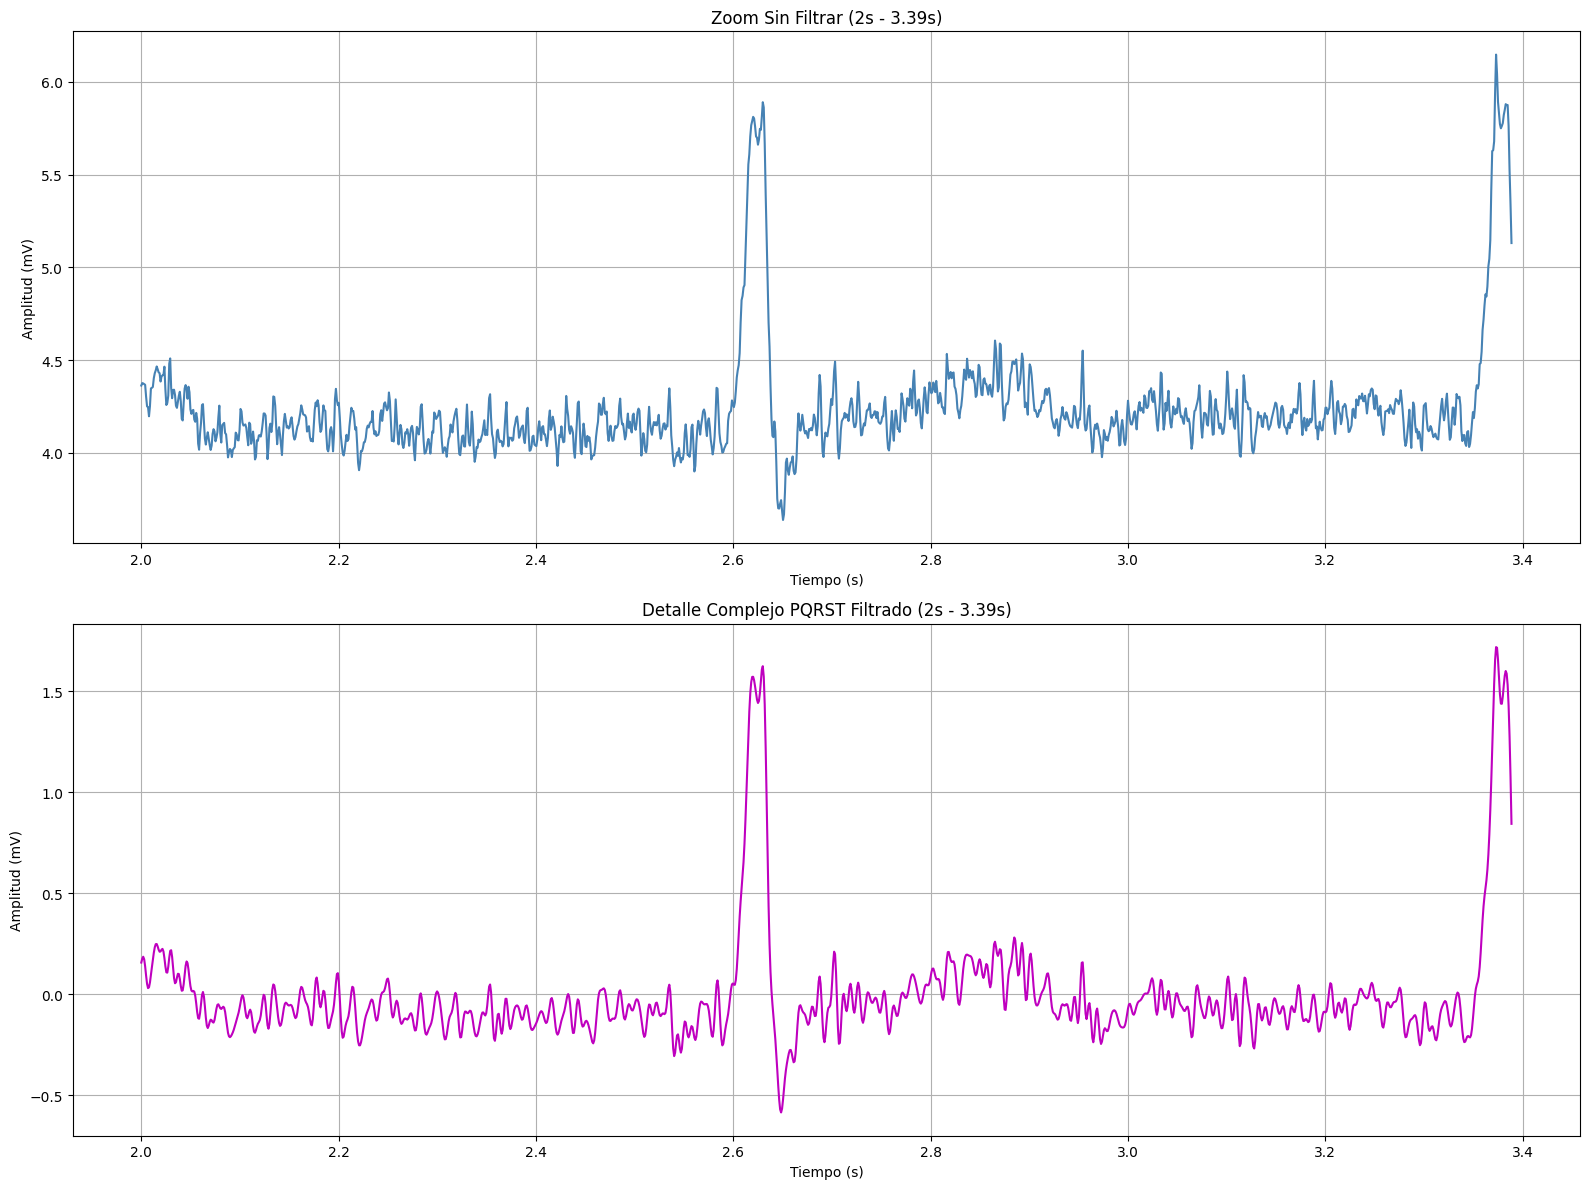

Frecuencia de muestreo: 1024 Hz
Máximo amplitud detectado para el filtrado: 2.0033 mV
Máximo amplitud detectado para el filtrado: 6.6436 mV


In [5]:
# ZOOM 
# Definir el segmento de tiempo para el zoom (en segundos)
seg_inicio = 2
seg_fin = 3.39
idx_ini = int(seg_inicio * Fs)
idx_fin = int(seg_fin * Fs)

#CREACIÓN DE LAS GRÁFICAS
plt.figure(figsize=(16, 12))


# ZOOM SIN FILTRAR
plt.subplot(2, 1, 1)
plt.plot(t[idx_ini:idx_fin], ecg_unfiltered[idx_ini:idx_fin], color='steelblue')
plt.title(f"Zoom Sin Filtrar ({seg_inicio}s - {seg_fin}s)", fontsize=12)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)

#  ZOOM FILTRADO 
plt.subplot(2, 1, 2)
plt.plot(t[idx_ini:idx_fin], ecg[idx_ini:idx_fin], color='m')
plt.title(f"Detalle Complejo PQRST Filtrado ({seg_inicio}s - {seg_fin}s)", fontsize=12)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)

# Ajuste automático para que no se solapen los títulos
plt.tight_layout()
plt.show()

# Imprimir info de control
print(f"Frecuencia de muestreo: {Fs} Hz")
print(f"Máximo amplitud detectado para el filtrado: {np.max(ecg):.4f} mV")


print(f"Máximo amplitud detectado para el filtrado: {np.max(ecg_unfiltered):.4f} mV")

Realizamos un zoom de las señales para la verificación de lo mencionado anteriormente, se observa que los complejos PQRST si son más notables después de filtrada la señal, sin embargo se sigue dando sugerencia de filtro notch para una señal más limpia.

In [6]:
#Cálculo del valor RMS de la señal EMG filtrada
rms_value = rms(ecg)
print(f"Valor RMS de la señal EMG: {rms_value}")

Valor RMS de la señal EMG: 0.286305571152495



--- ECG sin filtrar ---
Picos encontrados : 38
Duración 1er ciclo: 0.845 s


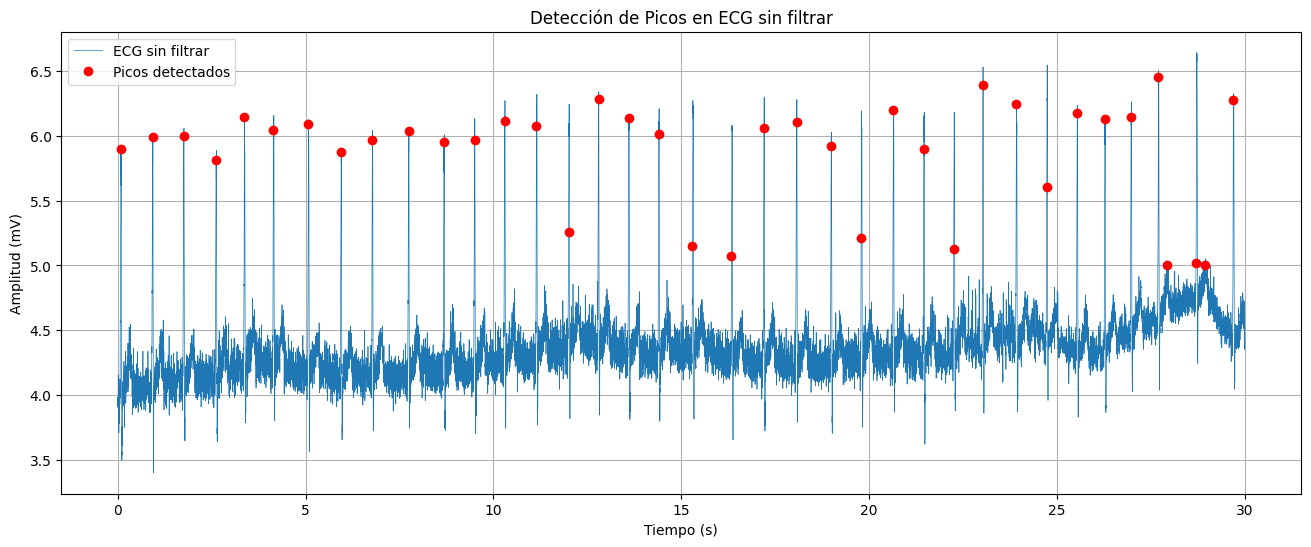


Duración del ciclo : 0.830 s  (~72 bpm)
Promedio           : 4.1793 mV
Valor RMS          : 4.1906
Varianza           : 0.0944 mV²
Desv. estándar     : 0.3072 mV


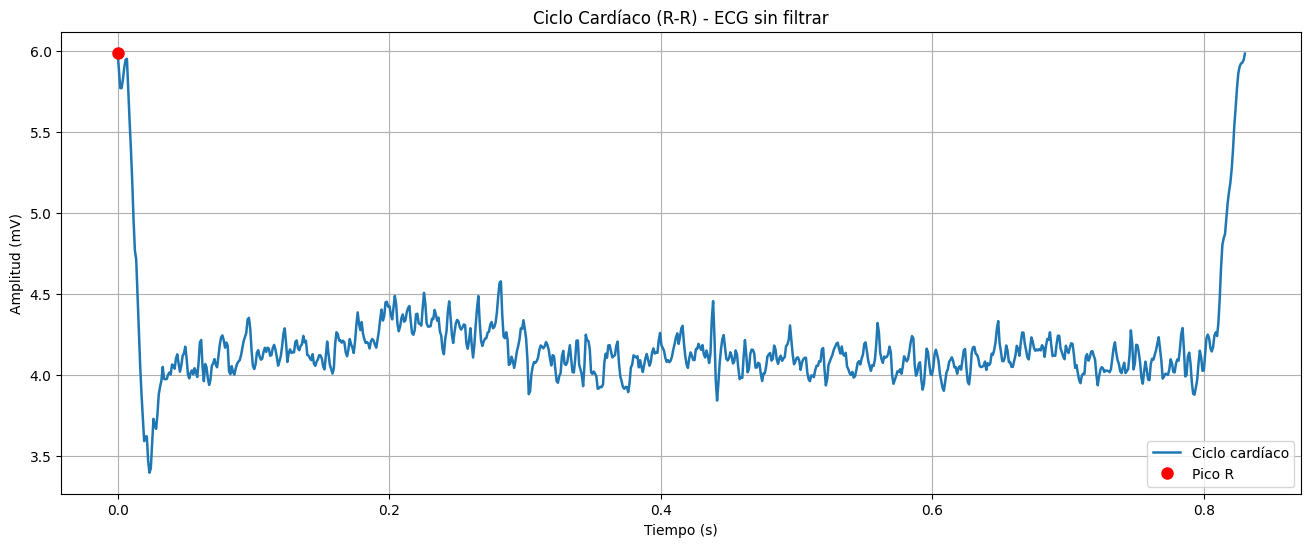

In [7]:
def analizar_ecg(ecg_signal, t, umbral, nombre):

    # Detector de picos
    picos = []
    distancia_minima = 100

    for i in range(1, len(ecg_signal) - 1):
        if ecg_signal[i] > ecg_signal[i-1] and ecg_signal[i] > ecg_signal[i+1]:
            if ecg_signal[i] > umbral:
                if len(picos) == 0 or (i - picos[-1]) > distancia_minima:
                    picos.append(i)

    picos = np.array(picos)

    print(f"\n--- {nombre} ---")
    print(f"Picos encontrados : {len(picos)}")
    print(f"Duración 1er ciclo: {t[picos[1]] - t[picos[0]]:.3f} s")

    # Gráfica de señal completa con picos
    plt.figure(figsize=(16,6))
    plt.plot(t, ecg_signal, linewidth=0.5, label=nombre)
    plt.plot(t[picos], ecg_signal[picos], 'ro', label='Picos detectados')
    plt.title(f"Detección de Picos en {nombre}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (mV)")
    plt.legend()
    plt.grid()
    plt.show()

    # Extraer ciclo
    ciclo_num = 1
    i_inicio = picos[ciclo_num]
    i_fin = picos[ciclo_num + 1]

    ciclo = ecg_signal[i_inicio:i_fin]
    ciclo_t = t[i_inicio:i_fin] - t[i_inicio]

    # Estadísticas
    promedio = np.mean(ciclo)
    valor_rms = rms(ciclo)
    varianza = np.var(ciclo)
    std = np.std(ciclo)

    print(f"\nDuración del ciclo : {ciclo_t[-1]:.3f} s  (~{60/ciclo_t[-1]:.0f} bpm)")
    print(f"Promedio           : {promedio:.4f} mV")
    print(f"Valor RMS          : {valor_rms:.4f}")
    print(f"Varianza           : {varianza:.4f} mV²")
    print(f"Desv. estándar     : {std:.4f} mV")

    # Gráfica del ciclo
    plt.figure(figsize=(16,6))
    plt.plot(ciclo_t, ciclo, linewidth=1.8, label='Ciclo cardíaco')
    plt.plot(0, ciclo[0], 'ro', markersize=8, label='Pico R')
    plt.title(f"Ciclo Cardíaco (R-R) - {nombre}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (mV)")
    plt.legend()
    plt.grid()
    plt.show()

analizar_ecg(ecg_unfiltered, t, umbral=5, nombre="ECG sin filtrar")

Se evaluó la duración del ciclo cardíaco utilizando la fórmula de frecuencia cardíaca: FC (bpm) = 60/ Intervalo R-R (s). Con una duración medida de 0.830 s, se obtuvo una frecuencia aproximada de 72 bpm, lo cual se corresponde con un ritmo cardíaco en reposo dentro de los rangos normales para un adulto.

Respecto al Promedio (4.1793 mV), este valor indica un fuerte desplazamiento de corriente continua (nivel DC) en la señal. En un electrocardiograma (ECG) ideal, el promedio debería ser cercano a cero; no obstante, el valor obtenido evidencia un offset positivo significativo en la adquisición.

Por otro lado, la Varianza (0.0944 mV²) y la Desviación Estándar (0.3072 mV) presentan valores bajos. Esto verifica que los datos no presentan una dispersión excesiva en el tiempo, lo que sugiere que los complejos QRST se mantienen en un rango de amplitud razonable y constante, a pesar del desplazamiento hacia arriba en el eje de tensión.

Finalmente, el valor RMS (4.1906 mV) resulta ser muy elevado y casi idéntico al promedio. Esto es un indicador técnico de que la energía de la señal no proviene principalmente de la actividad eléctrica pulsátil del corazón, sino de un nivel de ruido DC constante de fondo que predomina sobre los picos biológicos.


--- ECG filtrado ---
Picos encontrados : 36
Duración 1er ciclo: 0.844 s


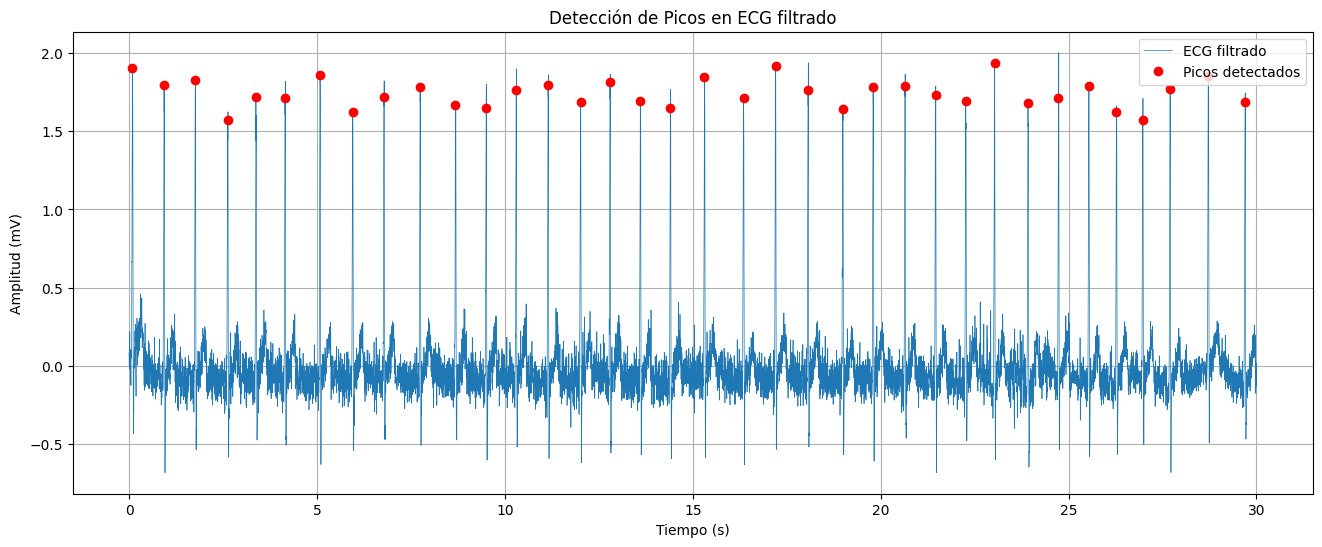


Duración del ciclo : 0.833 s  (~72 bpm)
Promedio           : -0.0015 mV
Valor RMS          : 0.3237
Varianza           : 0.1048 mV²
Desv. estándar     : 0.3237 mV


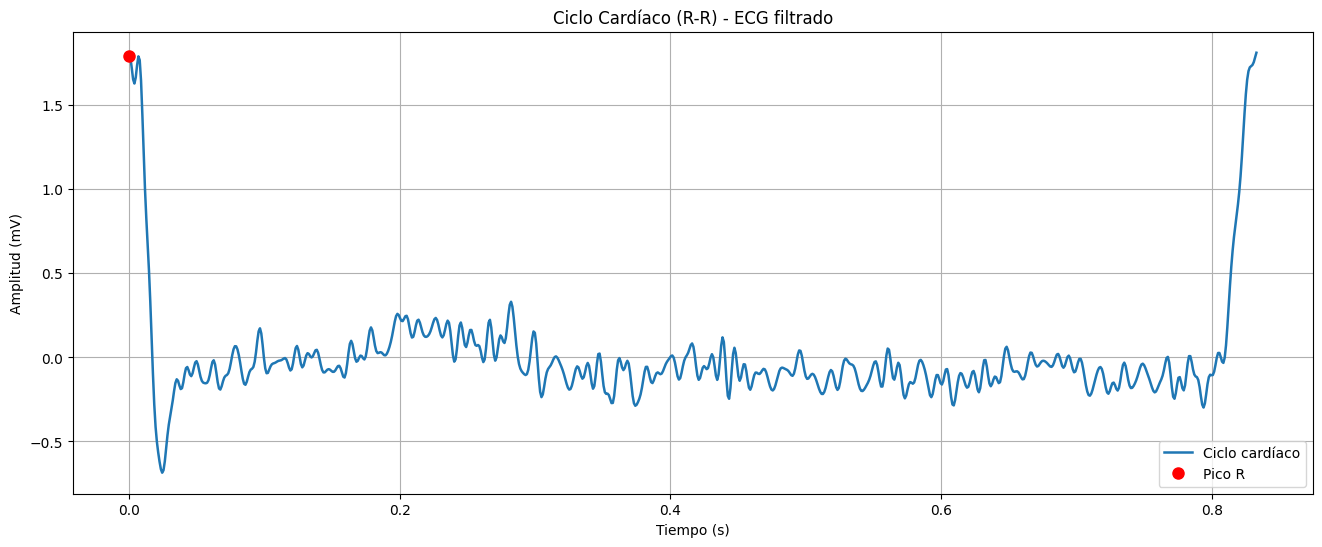

In [8]:
analizar_ecg(ecg, t, 1.5, "ECG filtrado")

Tras aplicar el filtrado se observa que se obtuvo una señal mucho más limpia, ahora es prácticamente cero. Esto indica que se ha eliminado con éxito el desplazamiento de nivel DC (offset) y el ruido de baja frecuencia (deriva de la línea base), centrando la señal correctamente en el eje de equilibrio.

Para el valor de RMS (0.3237 mV) se observa que es idéntico a la desviación estándar (0.3237 mV).Esto ocurre porque, ya se tiene una señal filtrada en donde la variabilidad de los componentes del ECG ahora correponde a los complejos PQRST y no al ruido captado en la señal cruda.

La varianza 0.1048 mV² de  aumento respecto a la señal original es un indicador positivo, refleja que al eliminar el ruido, se tiene la señal real del corazón, obteniendo una mejor visualización de la morfología del complejo.

Por último,la duración de 0.833 s mantiene una frecuencia de 72 bpm, lo que confirma que el filtrado no alteró la información temporal esencial del ritmo cardíaco.

In [9]:
# Detector simple de picos R
picos = []
for i in range(1, len(ecg)-1):
    if ecg[i] > ecg[i-1] and ecg[i] > ecg[i+1] and ecg[i] > 1.5:
        picos.append(i)

picos = np.array(picos)

In [ ]:
ciclos = [] #Extracción de 15 ciclos.

for i in range(15):
    inicio = picos[i]
    fin = picos[i+1]
    ciclo = ecg[inicio:fin]
    ciclos.append(ciclo)

In [ ]:
promedios = [] #para saber los promedios y las varianzas de los 15 ciclos, sacados de la señal FILTRADA.
varianzas = []

for ciclo in ciclos:
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

print("Promedios:", promedios)
print("Varianzas:", varianzas)

Promedios: [np.float64(0.07400995782055861), np.float64(1.7113657781036102), np.float64(-0.015618184428254531), np.float64(-0.027816520462519697), np.float64(1.5141017240614614), np.float64(-0.02097517799737753), np.float64(1.5606587228083633), np.float64(0.002628631068156254), np.float64(1.6793134092653288), np.float64(-0.02794373421958412), np.float64(0.0004307868593682338), np.float64(1.6095824834381156), np.float64(-0.005861152214043872), np.float64(1.7139742275065646), np.float64(-0.022631368004353537)]
Varianzas: [np.float64(0.09668431488232455), np.float64(0.0035197079801759204), np.float64(0.08118090892446858), np.float64(0.05655525326369125), np.float64(0.0028223536481061214), np.float64(0.04683901969414558), np.float64(0.010217315290873588), np.float64(0.05565364819599988), np.float64(0.003069615014722733), np.float64(0.05814758951151242), np.float64(0.0777072812017751), np.float64(8.240979998675622e-05), np.float64(0.056187250097744626), np.float64(0.0018255276103581743), np

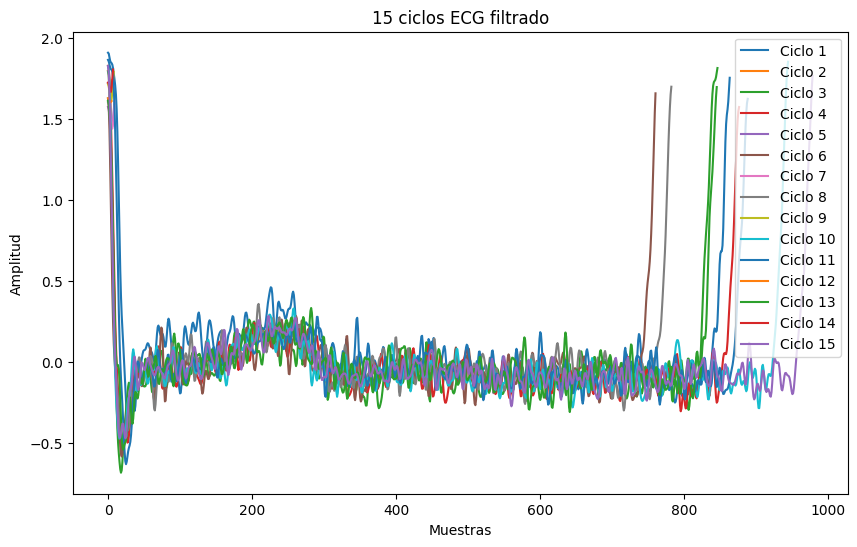

In [12]:
#Graficamos 15 ciclos 
plt.figure(figsize=(10,6))

for i, ciclo in enumerate(ciclos):
    plt.plot(ciclo, label=f'Ciclo {i+1}')

plt.title("15 ciclos ECG filtrado")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

A partir de los 15 ciclos extraídos de la señal ECG filtrada se calcularon el promedio y la varianza para cada ciclo.

Los promedios presentan variaciones importantes entre ciclos. Algunos ciclos tienen valores cercanos a 0 (por ejemplo −0.0278, −0.0209, 0.0026), mientras que otros presentan valores alrededor de 1.5–1.7.Esto indica que el nivel medio de la señal cambia significativamente entre ciclos, lo cual sugiere que la media no se mantiene constante en el tiempo.

Por otro lado,las varianzas también presentan cambios entre ciclos, con valores que van aproximadamente desde 0.00008 hasta 0.096.

En conclusión, Debido a que ni el promedio ni la varianza permanecen aproximadamente constantes entre los ciclos, se puede concluir que la señal no cumple completamente la condición de estacionariedad en sentido amplio en el intervalo analizado.

Sin embargo, estas variaciones pueden deberse a características fisiológicas propias del ECG o a pequeñas variaciones en la duración y amplitud de los ciclos cardiacos.

In [ ]:
#Comparación de los ciclos 
ciclo1 = ciclos[0] #este es el ciclo 1
ciclo2 = ciclos[5] #este es el ciclo 6

In [15]:
#Verificar normalidad
from scipy.stats import shapiro

print(shapiro(ciclo1))
print(shapiro(ciclo2)) 

ShapiroResult(statistic=np.float64(0.6182283875962342), pvalue=np.float64(6.428306789252381e-40))
ShapiroResult(statistic=np.float64(0.6606662453960939), pvalue=np.float64(2.5586738564090947e-36))


Se aplicó la prueba de Shapiro-Wilk para evaluar si los datos de cada ciclo siguen una distribución normal.

Resultados obtenidos:
Ciclo 1:
p = 6.43 × 10⁻⁴⁰
Ciclo 6:
p = 2.56 × 10⁻³⁶
Dado que en ambos casos p < 0.05, se rechaza la hipótesis nula de normalidad.
Esto indica que los datos de los ciclos NO siguen una distribución normal.

In [14]:
#Supuesto de homocedasticidad
from scipy.stats import levene

print(levene(ciclo1, ciclo2))


LeveneResult(statistic=np.float64(18.34821953535173), pvalue=np.float64(1.9477989212285043e-05))


Para evaluar si las varianzas de los ciclos son iguales se aplicó la prueba de Levene.

Resultado obtenido:
p = 1.95 × 10⁻⁵
Debido a que p < 0.05, se rechaza la hipótesis de igualdad de varianzas.
Esto indica que los ciclos presentan varianzas significativamente diferentes, es decir,NO existe homocedasticidad. 

No se hace prueba T, debido a que los supuestos de normalidad y homocedasticidad, no se cumplen. Se hace prueba de Mann-Whitney (no paramétrica).

In [17]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(ciclo1, ciclo2)

print("U:", stat)
print("p:", p)

U: 413479.0
p: 2.7986427776871576e-19


In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(ecg)

print("ADF:", resultado[0])
print("p-value:", resultado[1])